# Logical Fallacy Detection - Progress 3
**Dataset:** CoCoLoFa (Comments with Common Logical Fallacies)
https://github.com/Crowd-AI-Lab/cocolofa

**Progress 3:** Tuned models with optimized TF-IDF features:
- **Models:** Linear SVC, Complement Naive Bayes, Logistic Regression
- **Text Representation:** Tuned TF-IDF (word and character n-gram candidates)
- **Comparison:** All models + Progress 2 models (TF-IDF and Word2Vec)

**Citation:**
Min-Hsuan Yeh, Ruyuan Wan, and Ting-Hao 'Kenneth' Huang. (2024). *CoCoLoFa: A Dataset of News Comments with Common Logical Fallacies Written by LLM-Assisted Crowds*. [arXiv:2410.03457](https://arxiv.org/abs/2410.03457)

## 0. Import Libraries

In [1]:
import json
import re
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, precision_recall_fscore_support
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

In [2]:
KAGGLE_PATH = '/kaggle/input/datasets/aristelcrowley/cocolofa'

if os.path.exists(KAGGLE_PATH):
    DATA_DIR = KAGGLE_PATH
    print(f"Running on Kaggle (dataset: {DATA_DIR})")
else:
    DATA_DIR = 'data'   
    print("Running locally")

# Load train data
file_path = os.path.join(DATA_DIR, 'train.json')
with open(file_path, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)
    
records = []
for article in raw_data:
    for comment in article['comments']:
        records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df = pd.DataFrame(records)

# Load test data
with open(os.path.join(DATA_DIR, 'test.json'), 'r', encoding='utf-8') as f:
    test_raw = json.load(f)

test_records = []
for article in test_raw:
    for comment in article['comments']:
        test_records.append({
            'comment_id': comment['id'],
            'news_id': comment['news_id'],
            'fallacy': comment['fallacy'],
            'comment': comment['comment']
        })

df_test = pd.DataFrame(test_records)

print(f"Total train comments: {len(df)}")
print(f"Total test comments: {len(df_test)}")
print(f"\nDistribusi label fallacy (train):")
print(df['fallacy'].value_counts())

Running locally
Total train comments: 5370
Total test comments: 798

Distribusi label fallacy (train):
fallacy
none                        2202
slippery slope               431
appeal to worse problems     421
appeal to nature             412
appeal to tradition          401
false dilemma                391
appeal to majority           383
hasty generalization         379
appeal to authority          350
Name: count, dtype: int64


## 2. Text Cleaning

In [3]:
def clean_text(text):
    """Clean raw text."""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned'] = df['comment'].apply(clean_text)
df_test['cleaned'] = df_test['comment'].apply(clean_text)

print("Text cleaning complete.")

Text cleaning complete.


## 3. Tokenization

In [4]:
df['tokens'] = df['cleaned'].apply(word_tokenize)
df_test['tokens'] = df_test['cleaned'].apply(word_tokenize)

print("Tokenization complete.")

Tokenization complete.


## 4. Stopword Removal & Lemmatization

In [5]:
fallacy_indicators = {
    'everyone', 'always', 'never', 'must', 'should', 'all', 'every',
    'only', 'just', 'no', 'nothing', 'everything', 'most', 'any',
    'either', 'or', 'neither', 'nor', 'both', 'very', 'too',
}
stop_words = set(stopwords.words('english')) - fallacy_indicators
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [
        lemmatizer.lemmatize(token)
        for token in tokens
        if (token not in stop_words and len(token) > 2) or token in fallacy_indicators
    ]

df['lemmatized'] = df['tokens'].apply(lemmatize_tokens)
df_test['lemmatized'] = df_test['tokens'].apply(lemmatize_tokens)
df['processed_text'] = df['lemmatized'].apply(lambda x: ' '.join(x))
df_test['processed_text'] = df_test['lemmatized'].apply(lambda x: ' '.join(x))

print("Lemmatization complete.")

Lemmatization complete.


## 5. Label Encoding

In [6]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['fallacy'])
df_test['label'] = label_encoder.transform(df_test['fallacy'])

print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i} → {cls} ({count} samples)")

Number of classes: 9

Label mapping:
  0 → appeal to authority (350 samples)
  1 → appeal to majority (383 samples)
  2 → appeal to nature (412 samples)
  3 → appeal to tradition (401 samples)
  4 → appeal to worse problems (421 samples)
  5 → false dilemma (391 samples)
  6 → hasty generalization (379 samples)
  7 → none (2202 samples)
  8 → slippery slope (431 samples)


## 6. Train/Validation/Test Split (80/10/10)

In [7]:
df_train, df_val = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df['label']
)

print(f"Train set size: {len(df_train)}")
print(f"Validation set size: {len(df_val)}")
print(f"Test set size: {len(df_test)}")

Train set size: 4564
Validation set size: 806
Test set size: 798


---
## 7. Text Representation: Tuned TF-IDF

In [8]:
# Tune TF-IDF representation first (fast probe using Linear SVC)
vectorizer_candidates = [
    {
        'name': 'word_1_2_12k',
        'builder': lambda: TfidfVectorizer(
            analyzer='word',
            max_features=12000,
            ngram_range=(1, 2),
            sublinear_tf=True,
            min_df=2,
            max_df=0.95,
        )
    },
    {
        'name': 'word_1_3_18k',
        'builder': lambda: TfidfVectorizer(
            analyzer='word',
            max_features=18000,
            ngram_range=(1, 3),
            sublinear_tf=True,
            min_df=2,
            max_df=0.95,
        )
    },
    {
        'name': 'word_char_hybrid',
        'builder': lambda: FeatureUnion([
            ('word', TfidfVectorizer(
                analyzer='word',
                max_features=12000,
                ngram_range=(1, 2),
                sublinear_tf=True,
                min_df=2,
                max_df=0.95,
            )),
            ('char', TfidfVectorizer(
                analyzer='char_wb',
                max_features=15000,
                ngram_range=(3, 5),
                sublinear_tf=True,
                min_df=2,
            ))
        ])
    }
]

y_train_local = df_train['label'].values
y_val_local = df_val['label'].values

probe_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

vectorizer_search_results = []
for cfg in vectorizer_candidates:
    candidate_vectorizer = cfg['builder']()
    X_train_candidate = candidate_vectorizer.fit_transform(df_train['processed_text'])
    X_val_candidate = candidate_vectorizer.transform(df_val['processed_text'])

    probe_model.fit(X_train_candidate, y_train_local)
    y_val_probe = probe_model.predict(X_val_candidate)

    val_acc = accuracy_score(y_val_local, y_val_probe)
    val_f1 = f1_score(y_val_local, y_val_probe, average='weighted')

    vectorizer_search_results.append({
        'name': cfg['name'],
        'val_accuracy': val_acc,
        'val_f1_weighted': val_f1,
        'vectorizer': candidate_vectorizer,
        'X_train': X_train_candidate,
        'X_val': X_val_candidate,
    })

vectorizer_df = pd.DataFrame([
    {
        'TF-IDF Setup': r['name'],
        'Val Accuracy': r['val_accuracy'],
        'Val F1 (weighted)': r['val_f1_weighted'],
    }
    for r in vectorizer_search_results
]).sort_values(['Val F1 (weighted)', 'Val Accuracy'], ascending=False).reset_index(drop=True)
vectorizer_df.index += 1

best_vectorizer_result = max(
    vectorizer_search_results,
    key=lambda r: (r['val_f1_weighted'], r['val_accuracy'])
)
best_vectorizer_name = best_vectorizer_result['name']
tfidf_vectorizer = best_vectorizer_result['vectorizer']
X_train_tfidf = best_vectorizer_result['X_train']
X_val_tfidf = best_vectorizer_result['X_val']
X_test_tfidf = tfidf_vectorizer.transform(df_test['processed_text'])

print("TF-IDF tuning complete.")
print(f"Selected vectorizer: {best_vectorizer_name}")
display(vectorizer_df.style.format({
    'Val Accuracy': '{:.4f}',
    'Val F1 (weighted)': '{:.4f}'
}).background_gradient(subset=['Val F1 (weighted)'], cmap='Greens'))

print(f"\nTF-IDF Matrix Shapes (selected setup):")
print(f"  Train: {X_train_tfidf.shape}")
print(f"  Validation: {X_val_tfidf.shape}")
print(f"  Test: {X_test_tfidf.shape}")

TF-IDF tuning complete.
Selected vectorizer: word_1_3_18k


,TF-IDF Setup,Val Accuracy,Val F1 (weighted)
1,word_1_3_18k,0.6625,0.6614
2,word_1_2_12k,0.6563,0.6566
3,word_char_hybrid,0.6414,0.6418



TF-IDF Matrix Shapes (selected setup):
  Train: (4564, 18000)
  Validation: (806, 18000)
  Test: (798, 18000)


In [9]:
y_train = df_train['label'].values
y_val = df_val['label'].values
y_test = df_test['label'].values

---
## 8. Load Progress 2 Models for Comparison

In [10]:
def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.wv.vector_size)
    return np.mean(vectors, axis=0)

In [11]:
# Load Progress 2 models
p2_logreg_tfidf = joblib.load('models/progress_2/logistic_regression_tfidf.joblib')
p2_logreg_w2v = joblib.load('models/progress_2/logistic_regression_w2v.joblib')
p2_tfidf_vectorizer = joblib.load('models/progress_2/tfidf_vectorizer.joblib')
p2_w2v_model = joblib.load('models/progress_2/word2vec_model.joblib')
p2_info = joblib.load('models/progress_2/preprocessing_info.joblib')

print("Progress 2 models loaded!")
print(f"  LogReg + TF-IDF   → F1: {p2_info['models']['logreg_tfidf']['f1_weighted']:.4f}")
print(f"  LogReg + Word2Vec → F1: {p2_info['models']['logreg_w2v']['f1_weighted']:.4f}")

Progress 2 models loaded!
  LogReg + TF-IDF   → F1: 0.6830
  LogReg + Word2Vec → F1: 0.5165


In [12]:
# Prepare P2 test data using P2's vectorizers
X_test_tfidf_p2 = p2_tfidf_vectorizer.transform(df_test['processed_text'])
X_test_w2v_p2 = np.array([document_vector(tokens, p2_w2v_model) for tokens in df_test['lemmatized']])

# Evaluate P2 models on test data
y_pred_p2_logreg_tfidf = p2_logreg_tfidf.predict(X_test_tfidf_p2)
y_pred_p2_logreg_w2v = p2_logreg_w2v.predict(X_test_w2v_p2)

print("Progress 2 models evaluated on test data.")

Progress 2 models evaluated on test data.


---
## 9. Model 1: Tuned Linear SVC

In [13]:
svc_candidates = [0.5, 1.0, 1.5, 2.0, 3.0]
svc_results = []

print("Tuning Linear SVC...")
for c_value in svc_candidates:
    model = LinearSVC(
        C=c_value,
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    )
    model.fit(X_train_tfidf, y_train)

    y_val_pred = model.predict(X_val_tfidf)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    svc_results.append({
        'C': c_value,
        'val_accuracy': val_acc,
        'val_f1_weighted': val_f1,
        'model': model
    })

svc_df = pd.DataFrame([
    {
        'C': r['C'],
        'Val Accuracy': r['val_accuracy'],
        'Val F1 (weighted)': r['val_f1_weighted']
    }
    for r in svc_results
]).sort_values(['Val F1 (weighted)', 'Val Accuracy'], ascending=False).reset_index(drop=True)
svc_df.index += 1

best_svc = max(svc_results, key=lambda r: (r['val_f1_weighted'], r['val_accuracy']))
model_svc_tfidf = best_svc['model']
y_val_pred_svc = model_svc_tfidf.predict(X_val_tfidf)
val_f1_svc = best_svc['val_f1_weighted']

print("Linear SVC tuning complete!")
print(f"Best C: {best_svc['C']}")
print(f"Best Validation Accuracy: {best_svc['val_accuracy']:.4f}")
print(f"Best Validation F1 (weighted): {val_f1_svc:.4f}")
display(svc_df.style.format({
    'Val Accuracy': '{:.4f}',
    'Val F1 (weighted)': '{:.4f}'
}).background_gradient(subset=['Val F1 (weighted)'], cmap='Greens'))

Tuning Linear SVC...
Linear SVC tuning complete!
Best C: 3.0
Best Validation Accuracy: 0.6712
Best Validation F1 (weighted): 0.6695


,C,Val Accuracy,Val F1 (weighted)
1,3.000000,0.6712,0.6695
2,2.000000,0.6700,0.6683
3,1.500000,0.6663,0.6648
4,1.000000,0.6625,0.6614
5,0.500000,0.6613,0.6609


---
## 10. Model 2: Tuned Complement Naive Bayes

In [14]:
cnb_candidates = [0.1, 0.3, 0.5, 0.7, 1.0]
cnb_results = []

print("Tuning Complement Naive Bayes...")
for alpha_value in cnb_candidates:
    model = ComplementNB(alpha=alpha_value)
    model.fit(X_train_tfidf, y_train)

    y_val_pred = model.predict(X_val_tfidf)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    cnb_results.append({
        'alpha': alpha_value,
        'val_accuracy': val_acc,
        'val_f1_weighted': val_f1,
        'model': model
    })

cnb_df = pd.DataFrame([
    {
        'alpha': r['alpha'],
        'Val Accuracy': r['val_accuracy'],
        'Val F1 (weighted)': r['val_f1_weighted']
    }
    for r in cnb_results
]).sort_values(['Val F1 (weighted)', 'Val Accuracy'], ascending=False).reset_index(drop=True)
cnb_df.index += 1

best_cnb = max(cnb_results, key=lambda r: (r['val_f1_weighted'], r['val_accuracy']))
model_cnb_tfidf = best_cnb['model']
y_val_pred_cnb = model_cnb_tfidf.predict(X_val_tfidf)
val_f1_cnb = best_cnb['val_f1_weighted']

print("Complement Naive Bayes tuning complete!")
print(f"Best alpha: {best_cnb['alpha']}")
print(f"Best Validation Accuracy: {best_cnb['val_accuracy']:.4f}")
print(f"Best Validation F1 (weighted): {val_f1_cnb:.4f}")
display(cnb_df.style.format({
    'Val Accuracy': '{:.4f}',
    'Val F1 (weighted)': '{:.4f}'
}).background_gradient(subset=['Val F1 (weighted)'], cmap='Greens'))

Tuning Complement Naive Bayes...
Complement Naive Bayes tuning complete!
Best alpha: 0.5
Best Validation Accuracy: 0.6588
Best Validation F1 (weighted): 0.6405


,alpha,Val Accuracy,Val F1 (weighted)
1,0.500000,0.6588,0.6405
2,0.300000,0.6427,0.6315
3,0.700000,0.6377,0.6120
4,0.100000,0.6129,0.6051
5,1.000000,0.5980,0.5532


---
## 11. Model 3: Tuned Logistic Regression

In [15]:
# Use a dedicated TF-IDF setup for Logistic Regression (accuracy-focused)
tfidf_vectorizer_logreg = TfidfVectorizer(
    analyzer='word',
    max_features=25000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    max_df=0.99,
 )

X_train_logreg = tfidf_vectorizer_logreg.fit_transform(df_train['processed_text'])
X_val_logreg = tfidf_vectorizer_logreg.transform(df_val['processed_text'])
X_test_logreg = tfidf_vectorizer_logreg.transform(df_test['processed_text'])

logreg_candidates = [2.0, 3.0, 4.0]
logreg_results = []

print("Tuning Logistic Regression (dedicated vectorizer)...")
for c_value in logreg_candidates:
    model = LogisticRegression(
        C=c_value,
        max_iter=4000,
        random_state=42,
        class_weight='balanced',
        solver='lbfgs'
    )
    model.fit(X_train_logreg, y_train)

    y_val_pred = model.predict(X_val_logreg)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    logreg_results.append({
        'C': c_value,
        'val_accuracy': val_acc,
        'val_f1_weighted': val_f1,
        'model': model
    })

logreg_df = pd.DataFrame([
    {
        'C': r['C'],
        'Val Accuracy': r['val_accuracy'],
        'Val F1 (weighted)': r['val_f1_weighted']
    }
    for r in logreg_results
]).sort_values(['Val Accuracy', 'Val F1 (weighted)'], ascending=False).reset_index(drop=True)
logreg_df.index += 1

best_logreg = max(logreg_results, key=lambda r: (r['val_accuracy'], r['val_f1_weighted']))
model_logreg_tfidf = best_logreg['model']
y_val_pred_logreg = model_logreg_tfidf.predict(X_val_logreg)
val_f1_logreg = best_logreg['val_f1_weighted']

print("Logistic Regression tuning complete!")
print("Vectorizer setup: word_1_2_25k_relaxed")
print(f"Best C: {best_logreg['C']}")
print(f"Best Validation Accuracy: {best_logreg['val_accuracy']:.4f}")
print(f"Best Validation F1 (weighted): {val_f1_logreg:.4f}")
display(logreg_df.style.format({
    'Val Accuracy': '{:.4f}',
    'Val F1 (weighted)': '{:.4f}'
}).background_gradient(subset=['Val Accuracy'], cmap='Blues'))

print(f"\nLogReg TF-IDF Matrix Shapes:")
print(f"  Train: {X_train_logreg.shape}")
print(f"  Validation: {X_val_logreg.shape}")
print(f"  Test: {X_test_logreg.shape}")

Tuning Logistic Regression (dedicated vectorizer)...
Logistic Regression tuning complete!
Vectorizer setup: word_1_2_25k_relaxed
Best C: 4.0
Best Validation Accuracy: 0.6675
Best Validation F1 (weighted): 0.6670


,C,Val Accuracy,Val F1 (weighted)
1,4.000000,0.6675,0.6670
2,3.000000,0.6613,0.6607
3,2.000000,0.6563,0.6557



LogReg TF-IDF Matrix Shapes:
  Train: (4564, 25000)
  Validation: (806, 25000)
  Test: (798, 25000)


---
## 12. Test Evaluation - All Models

In [16]:
# Test predictions for all P3 models
y_test_pred_svc = model_svc_tfidf.predict(X_test_tfidf)
y_test_pred_cnb = model_cnb_tfidf.predict(X_test_tfidf)
y_test_pred_logreg = model_logreg_tfidf.predict(X_test_logreg)

def get_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted'),
        'recall': recall_score(y_true, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'f1_macro': f1_score(y_true, y_pred, average='macro')
    }

results = {
    # Progress 2 models
    'P2: LogReg + TF-IDF': get_metrics(y_test, y_pred_p2_logreg_tfidf),
    'P2: LogReg + W2V': get_metrics(y_test, y_pred_p2_logreg_w2v),
    # Progress 3 tuned models
    'P3: Tuned Linear SVC': get_metrics(y_test, y_test_pred_svc),
    'P3: Tuned Complement NB': get_metrics(y_test, y_test_pred_cnb),
    'P3: Tuned LogReg': get_metrics(y_test, y_test_pred_logreg),
}

print("Test evaluation complete!")

Test evaluation complete!


---
## 13. Complete Model Comparison

In [17]:
comparison_data = []
for model_name, metrics in results.items():
    progress = model_name.split(':')[0]
    model_desc = model_name.split(': ')[1]
    
    comparison_data.append({
        'Progress': progress,
        'Model': model_desc,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 (weighted)': metrics['f1_weighted'],
        'F1 (macro)': metrics['f1_macro']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
comparison_df.index += 1

print("  PROGRESS 3 — Complete Model Comparison (P2 + P3, Ranked by Weighted F1)")
display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1 (weighted)': '{:.4f}',
    'F1 (macro)': '{:.4f}',
}).background_gradient(subset=['F1 (weighted)'], cmap='Greens'))

  PROGRESS 3 — Complete Model Comparison (P2 + P3, Ranked by Weighted F1)


,Progress,Model,Accuracy,Precision,Recall,F1 (weighted),F1 (macro)
1,P3,Tuned LogReg,0.6980,0.6913,0.6980,0.6934,0.6999
2,P2,LogReg + TF-IDF,0.6855,0.6889,0.6855,0.6830,0.6979
3,P3,Tuned Linear SVC,0.6830,0.6801,0.6830,0.6782,0.6766
4,P3,Tuned Complement NB,0.6404,0.6595,0.6404,0.6222,0.6036
5,P2,LogReg + W2V,0.5263,0.5722,0.5263,0.5165,0.5623


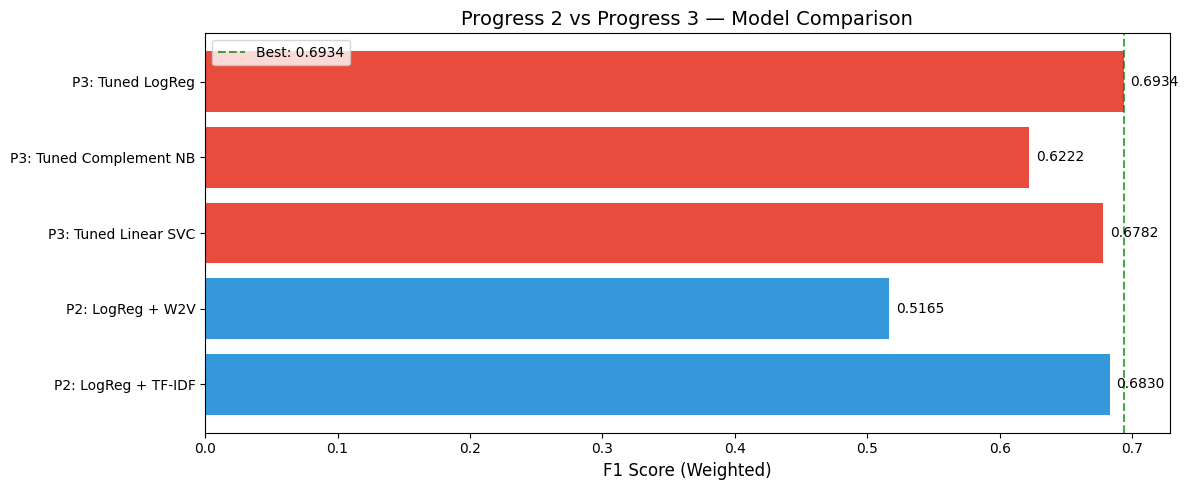

In [18]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))

model_names = list(results.keys())
f1_scores = [results[m]['f1_weighted'] for m in model_names]

colors = ['#3498db' if 'P2' in m else '#e74c3c' for m in model_names]
bars = ax.barh(model_names, f1_scores, color=colors)

ax.set_xlabel('F1 Score (Weighted)', fontsize=12)
ax.set_title('Progress 2 vs Progress 3 — Model Comparison', fontsize=14)
ax.axvline(x=max(f1_scores), color='green', linestyle='--', alpha=0.7, label=f'Best: {max(f1_scores):.4f}')

for bar, score in zip(bars, f1_scores):
    ax.text(score + 0.005, bar.get_y() + bar.get_height()/2, f'{score:.4f}', va='center', fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()

## 14. Best Model Analysis

In [19]:
# Find best P3 model
p3_results = {k: v for k, v in results.items() if 'P3' in k}
best_p3_name = max(p3_results, key=lambda x: p3_results[x]['f1_weighted'])
best_p3_metrics = p3_results[best_p3_name]

# Get predictions for best model
pred_mapping = {
    'P3: Tuned Linear SVC': y_test_pred_svc,
    'P3: Tuned Complement NB': y_test_pred_cnb,
    'P3: Tuned LogReg': y_test_pred_logreg,
}
best_pred = pred_mapping[best_p3_name]

print(f"  BEST PROGRESS 3 MODEL: {best_p3_name}")
print(f"\nTest Results:")
print(f"  Accuracy: {best_p3_metrics['accuracy']:.4f}")
print(f"  Precision: {best_p3_metrics['precision']:.4f}")
print(f"  Recall: {best_p3_metrics['recall']:.4f}")
print(f"  F1 (weighted): {best_p3_metrics['f1_weighted']:.4f}")
print(f"  F1 (macro): {best_p3_metrics['f1_macro']:.4f}")
print("\n" + classification_report(y_test, best_pred, target_names=label_encoder.classes_))

  BEST PROGRESS 3 MODEL: P3: Tuned LogReg

Test Results:
  Accuracy: 0.6980
  Precision: 0.6913
  Recall: 0.6980
  F1 (weighted): 0.6934
  F1 (macro): 0.6999

                          precision    recall  f1-score   support

     appeal to authority       0.72      0.64      0.68        56
      appeal to majority       0.74      0.83      0.78        59
        appeal to nature       0.84      0.93      0.88        55
     appeal to tradition       0.72      0.78      0.75        59
appeal to worse problems       0.73      0.75      0.74        64
           false dilemma       0.70      0.76      0.73        50
    hasty generalization       0.42      0.32      0.36        60
                    none       0.68      0.68      0.68       317
          slippery slope       0.71      0.68      0.69        78

                accuracy                           0.70       798
               macro avg       0.70      0.71      0.70       798
            weighted avg       0.69      0.70  

In [20]:
# Per-class F1 for best model
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    y_test, best_pred, average=None
)

per_class_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Support': support
}).sort_values('F1-Score', ascending=False)

print(f"  PER-CLASS F1 SCORES — {best_p3_name}")
display(per_class_df.style.format({
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'Support': '{:.0f}'
}).background_gradient(subset=['F1-Score'], cmap='Greens'))

  PER-CLASS F1 SCORES — P3: Tuned LogReg


,Class,Precision,Recall,F1-Score,Support
2,appeal to nature,0.8361,0.9273,0.8793,55
1,appeal to majority,0.7424,0.8305,0.7840,59
3,appeal to tradition,0.7188,0.7797,0.7480,59
4,appeal to worse problems,0.7273,0.7500,0.7385,64
5,false dilemma,0.7037,0.7600,0.7308,50
8,slippery slope,0.7067,0.6795,0.6928,78
7,none,0.6845,0.6845,0.6845,317
0,appeal to authority,0.7200,0.6429,0.6792,56
6,hasty generalization,0.4222,0.3167,0.3619,60


## 15. Confusion Matrices

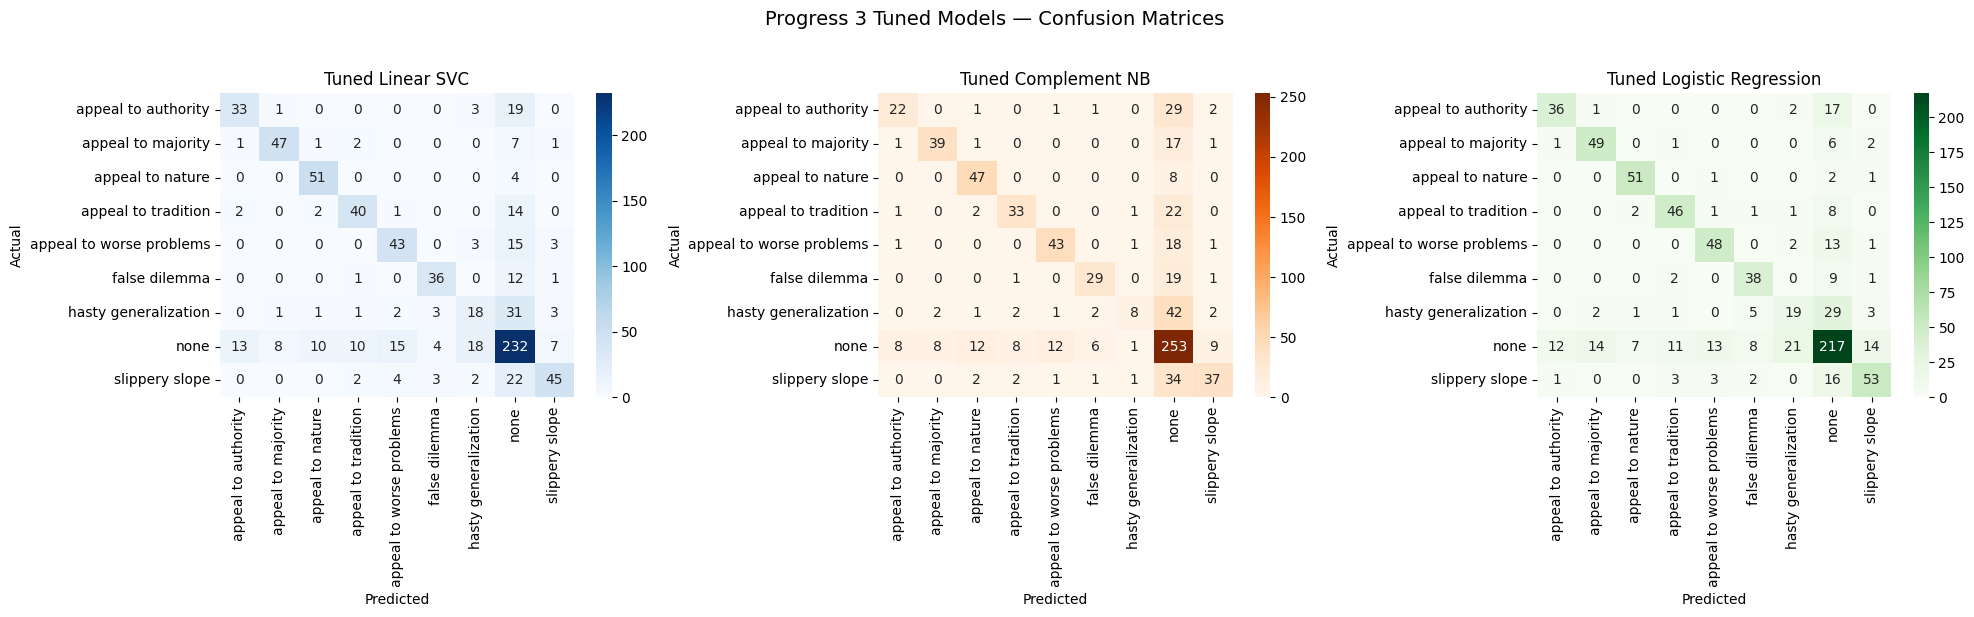

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cm_svc = confusion_matrix(y_test, y_test_pred_svc)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[0].set_title('Tuned Linear SVC', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_cnb = confusion_matrix(y_test, y_test_pred_cnb)
sns.heatmap(cm_cnb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[1].set_title('Tuned Complement NB', fontsize=12)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

cm_logreg = confusion_matrix(y_test, y_test_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[2].set_title('Tuned Logistic Regression', fontsize=12)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Progress 3 Tuned Models — Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 16. Save Models

In [22]:
os.makedirs('models/progress_3', exist_ok=True)

# Save all tuned P3 models
joblib.dump(model_svc_tfidf, 'models/progress_3/linear_svc_tfidf.joblib')
joblib.dump(model_cnb_tfidf, 'models/progress_3/complement_nb_tfidf.joblib')
joblib.dump(model_logreg_tfidf, 'models/progress_3/logistic_regression_tfidf.joblib')

# Save vectorizers and encoder
joblib.dump(tfidf_vectorizer, 'models/progress_3/tfidf_vectorizer.joblib')
joblib.dump(tfidf_vectorizer_logreg, 'models/progress_3/tfidf_vectorizer_logreg.joblib')
joblib.dump(label_encoder, 'models/progress_3/label_encoder.joblib')

# Save results and tuning info
p3_info = {
    'fallacy_indicators': list(fallacy_indicators),
    'vectorizer_setup': {
        'svc_cnb': best_vectorizer_name,
        'logreg': 'word_1_2_25k_relaxed'
    },
    'model_params': {
        'linear_svc': {'C': best_svc['C']},
        'complement_nb': {'alpha': best_cnb['alpha']},
        'logistic_regression': {'C': best_logreg['C']},
    },
    'models': {k: v for k, v in results.items() if k.startswith('P3:')},
    'best_model': best_p3_name
}
joblib.dump(p3_info, 'models/progress_3/preprocessing_info.joblib')

print("All models saved to models/progress_3/")
print("\nSaved files:")
for f in sorted(os.listdir('models/progress_3')):
    print(f"  - {f}")

All models saved to models/progress_3/

Saved files:
  - complement_nb_tfidf.joblib
  - label_encoder.joblib
  - linear_svc_tfidf.joblib
  - logistic_regression_tfidf.joblib
  - preprocessing_info.joblib
  - tfidf_vectorizer.joblib
  - tfidf_vectorizer_logreg.joblib


## 17. Summary

In [23]:
print("  PROGRESS 3 SUMMARY")
print(f"\nNew Models: Tuned Linear SVC, Tuned Complement NB, Tuned Logistic Regression")
print(f"Text Representation: Tuned TF-IDF")
print(f"Selected TF-IDF setup (SVC/CNB): {best_vectorizer_name}")
print(f"Selected TF-IDF setup (LogReg): word_1_2_25k_relaxed")
print(f"\nData Split:")
print(f"  Train: {len(df_train)} samples")
print(f"  Validation: {len(df_val)} samples")
print(f"  Test: {len(df_test)} samples")
print(f"\nTest Results (F1 Weighted):")
print(f"  {'Model':<30} {'F1':>10}")
print(f"  {'-'*40}")
for name, metrics in sorted(results.items(), key=lambda x: x[1]['f1_weighted'], reverse=True):
    print(f"  {name:<30} {metrics['f1_weighted']:>10.4f}")
print(f"\nBest Progress 3 Model: {best_p3_name}")
print(f"  Accuracy: {best_p3_metrics['accuracy']:.4f}")
print(f"  F1 (weighted): {best_p3_metrics['f1_weighted']:.4f}")
print(f"\nModels saved to: models/progress_3/")

  PROGRESS 3 SUMMARY

New Models: Tuned Linear SVC, Tuned Complement NB, Tuned Logistic Regression
Text Representation: Tuned TF-IDF
Selected TF-IDF setup (SVC/CNB): word_1_3_18k
Selected TF-IDF setup (LogReg): word_1_2_25k_relaxed

Data Split:
  Train: 4564 samples
  Validation: 806 samples
  Test: 798 samples

Test Results (F1 Weighted):
  Model                                  F1
  ----------------------------------------
  P3: Tuned LogReg                   0.6934
  P2: LogReg + TF-IDF                0.6830
  P3: Tuned Linear SVC               0.6782
  P3: Tuned Complement NB            0.6222
  P2: LogReg + W2V                   0.5165

Best Progress 3 Model: P3: Tuned LogReg
  Accuracy: 0.6980
  F1 (weighted): 0.6934

Models saved to: models/progress_3/


---
## 18. Local Inference (Single Input)

Available models: `svc`, `cnb`, `logreg`

In [24]:
import joblib
import re
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Choose model: 'svc', 'cnb', 'logreg'
MODEL_CHOICE = 'svc'

model_files = {
    'svc': 'models/progress_3/linear_svc_tfidf.joblib',
    'cnb': 'models/progress_3/complement_nb_tfidf.joblib',
    'logreg': 'models/progress_3/logistic_regression_tfidf.joblib',
}
vectorizer_files = {
    'svc': 'models/progress_3/tfidf_vectorizer.joblib',
    'cnb': 'models/progress_3/tfidf_vectorizer.joblib',
    'logreg': 'models/progress_3/tfidf_vectorizer_logreg.joblib',
}

if MODEL_CHOICE not in model_files:
    raise ValueError(f"Invalid MODEL_CHOICE: {MODEL_CHOICE}. Use one of {list(model_files.keys())}")

model = joblib.load(model_files[MODEL_CHOICE])
vectorizer = joblib.load(vectorizer_files[MODEL_CHOICE])
label_encoder = joblib.load('models/progress_3/label_encoder.joblib')
info = joblib.load('models/progress_3/preprocessing_info.joblib')
fallacy_indicators = set(info['fallacy_indicators'])

stop_words = set(stopwords.words('english')) - fallacy_indicators
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if (token not in stop_words and len(token) > 2) or token in fallacy_indicators
    ]
    return ' '.join(tokens)

def predict_fallacy(text):
    processed = preprocess_text(text)
    features = vectorizer.transform([processed])
    prediction = model.predict(features)[0]
    return label_encoder.inverse_transform([prediction])[0]

# Test
test_text = "Everyone knows this is true. All experts agree."
result = predict_fallacy(test_text)
print(f"Model: {MODEL_CHOICE}")
print(f"Input: {test_text}")
print(f"Predicted fallacy: {result}")

Model: svc
Input: Everyone knows this is true. All experts agree.
Predicted fallacy: appeal to authority
